# Lecture 5 — Loss Functions and Optimization
## Lab Notebook · Deep Learning · UCU

---

### Overview
In Notebook 3, we explored **deep neural networks** and saw that depth dramatically increases expressiveness per parameter. But we used default settings for everything else — Adam optimizer, default initialization, cross-entropy loss. Where do these choices come from? Do they matter?

In this notebook, we peel back those defaults. From Lecture 5, we know that **loss functions** arise from the maximum likelihood recipe: choose a probability distribution over outputs, and minimize the negative log-likelihood. We also learned that **optimizers** vary widely in how they navigate the loss landscape, and that **initialization** can make or break training in deep networks.

By the end of this notebook, you will:
1. **Derive** loss functions from the maximum likelihood recipe and implement them from scratch
2. **Inspect** gradients computed by backpropagation and verify them manually
3. **Compare** SGD, SGD with momentum, and Adam on the same architecture
4. **Diagnose** vanishing/exploding gradients and fix them with He initialization
5. **Experiment** with learning rates, batch sizes, and learning rate schedules

### Useful References

| Resource | Link |
|----------|------|
| PyTorch `torch.optim` | [pytorch.org/docs/stable/optim.html](https://pytorch.org/docs/stable/optim.html) |
| PyTorch `torch.nn.init` | [pytorch.org/docs/stable/nn.init.html](https://pytorch.org/docs/stable/nn.init.html) |
| PyTorch Loss Functions | [pytorch.org/docs/stable/nn.html#loss-functions](https://pytorch.org/docs/stable/nn.html#loss-functions) |
| FashionMNIST dataset | [github.com/zalandoresearch/fashion-mnist](https://github.com/zalandoresearch/fashion-mnist) |
| UCU Deep Learning — Lecture 5 notes | [../../lectures/lecture 5/notes.md](../../lectures/lecture%205/notes.md) |
| *Understanding Deep Learning* — Prince (2023) | Chapters 5, 6, 7 |

In [11]:
# Setup — run this cell first
try:
    import google.colab
    IN_COLAB = True
    !pip install -q torchinfo
except ImportError:
    IN_COLAB = False

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
import copy
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# UCU color palette
C1, C2, C3, C4, C5 = '#19326E', '#50ACB0', '#CD742A', '#A3477F', '#907FAB'
C6, C7 = '#4294CC', '#89A943'

Using device: cpu


In [12]:
# Load FashionMNIST — shared across all sections
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Input shape      : {train_dataset[0][0].shape}")
print(f"Number of classes : {len(class_names)}")

Training samples : 60000
Test samples     : 10000
Input shape      : torch.Size([1, 28, 28])
Number of classes : 10


---

## 1. Loss Functions from Maximum Likelihood

From Lecture 5, we know that loss functions aren't arbitrary choices — they follow from a **recipe**:

1. Choose a probability distribution $Pr(\mathbf{y}|\boldsymbol{\theta})$ over the output domain
2. Let the network predict the distribution parameters: $\boldsymbol{\theta} = \mathbf{f}[\mathbf{x}, \boldsymbol{\phi}]$
3. Minimize the **negative log-likelihood**: $L[\boldsymbol{\phi}] = -\sum_i \log Pr(\mathbf{y}_i | \mathbf{f}[\mathbf{x}_i, \boldsymbol{\phi}])$

This recipe gives us **least squares** (from a Gaussian), **binary cross-entropy** (from a Bernoulli), and **multiclass cross-entropy** (from a categorical distribution). In this section, you'll implement each one from scratch and verify they match PyTorch's built-in versions.

### Exercise 1.1 — Mean Squared Error from scratch

For regression with Gaussian-distributed outputs, the negative log-likelihood reduces to the **least squares loss**:

$$L[\boldsymbol{\phi}] = \frac{1}{I}\sum_{i=1}^{I}(y_i - f[\mathbf{x}_i, \boldsymbol{\phi}])^2$$

Implement this loss function using basic PyTorch operations (no loops). Then verify it matches `nn.MSELoss()`.

In [13]:
def mse_loss_manual(y_pred, y_true):
    """Compute mean squared error loss.
    
    Args:
        y_pred: predictions, shape (N,) or (N, 1)
        y_true: targets, shape (N,) or (N, 1)
    Returns:
        scalar MSE loss
    """
    return torch.mean((y_pred - y_true)**2)

# Verify against PyTorch
torch.manual_seed(42)
y_pred = torch.randn(32)
y_true = torch.randn(32)

our_loss = mse_loss_manual(y_pred, y_true)
pytorch_loss = nn.MSELoss()(y_pred, y_true)

print(f"Our MSE loss    : {our_loss.item():.6f}")
print(f"PyTorch MSE loss: {pytorch_loss.item():.6f}")
assert torch.allclose(our_loss, pytorch_loss, atol=1e-6), "Losses don't match!"
print("✓ Losses match!")

Our MSE loss    : 2.342893
PyTorch MSE loss: 2.342893
✓ Losses match!


### Exercise 1.2 — Multiclass Cross-Entropy from scratch

For classification with $K$ classes, the network outputs $K$ raw **logits** $\mathbf{z} \in \mathbb{R}^K$. The **softmax** function converts these to probabilities:

$$\text{softmax}_k(\mathbf{z}) = \frac{\exp(z_k)}{\sum_{k'=1}^K \exp(z_{k'})}$$

The **cross-entropy loss** for a single sample with true class $c$ is:

$$\ell = -\log(\text{softmax}_c(\mathbf{z})) = -z_c + \log\sum_{k'=1}^K \exp(z_{k'})$$

Implement this in three steps:
1. Apply softmax to the logits
2. Select the probability of the correct class for each sample
3. Take negative log, average over the batch

Then verify it matches `nn.CrossEntropyLoss()`.

In [14]:
def cross_entropy_manual(logits, targets):
    """Compute multiclass cross-entropy loss from raw logits.
    
    Args:
        logits: raw network outputs, shape (N, K)
        targets: integer class labels, shape (N,)
    Returns:
        scalar cross-entropy loss (mean over batch)
    """
    # Step 1: apply softmax to logits (use torch.softmax or implement manually)
    probs = torch.softmax(logits, dim=1)
    
    # Step 2: select the probability of the correct class for each sample
    batch_size = logits.shape[0] # probs[i, targets[i]]
    correct_class_probs = probs[range(batch_size), targets]
    
    # Step 3: take negative log, then average over the batch
    return -torch.log(correct_class_probs + 1e-7).mean()

# Verify against PyTorch
torch.manual_seed(42)
logits = torch.randn(32, 10)  # batch of 32, 10 classes
targets = torch.randint(0, 10, (32,))

our_loss = cross_entropy_manual(logits, targets)
pytorch_loss = nn.CrossEntropyLoss()(logits, targets)

print(f"Our CE loss    : {our_loss.item():.6f}")
print(f"PyTorch CE loss: {pytorch_loss.item():.6f}")
assert torch.allclose(our_loss, pytorch_loss, atol=1e-5), "Losses don't match!"
print("✓ Losses match!")

Our CE loss    : 2.720167
PyTorch CE loss: 2.720169
✓ Losses match!


### Exercise 1.3 — Binary Cross-Entropy from scratch

For binary classification ($y \in \{0, 1\}$), the network outputs a single logit $z \in \mathbb{R}$. The **sigmoid** maps it to a probability:

$$\sigma(z) = \frac{1}{1 + \exp(-z)}$$

The **binary cross-entropy** loss is:

$$\ell = -(1 - y)\log(1 - \sigma(z)) - y\log(\sigma(z))$$

Implement this and verify against `nn.BCEWithLogitsLoss()`.

In [15]:
def bce_loss_manual(logits, targets):
    """Compute binary cross-entropy loss from raw logits.
    
    Args:
        logits: raw network outputs, shape (N,)
        targets: binary labels (0 or 1), shape (N,)
    Returns:
        scalar BCE loss (mean over batch)
    """
    # Hint: use torch.sigmoid() to convert logits to probabilities
    probs = torch.sigmoid(logits)
    # Add a small epsilon (1e-7) inside the log to avoid log(0)
    # Binary cross-entropy formula: -(y*log(p) + (1-y)*log(1-p))
    loss = -(targets * torch.log(probs + 1e-7) + (1 - targets) * torch.log(1 - probs + 1e-7))
    return loss.mean()

# Verify against PyTorch
torch.manual_seed(42)
logits = torch.randn(32)
targets = torch.randint(0, 2, (32,)).float()

our_loss = bce_loss_manual(logits, targets)
pytorch_loss = nn.BCEWithLogitsLoss()(logits, targets)

print(f"Our BCE loss    : {our_loss.item():.6f}")
print(f"PyTorch BCE loss: {pytorch_loss.item():.6f}")
assert torch.allclose(our_loss, pytorch_loss, atol=1e-4), "Losses don't match!"
print("✓ Losses match!")

Our BCE loss    : 0.716092
PyTorch BCE loss: 0.716093
✓ Losses match!


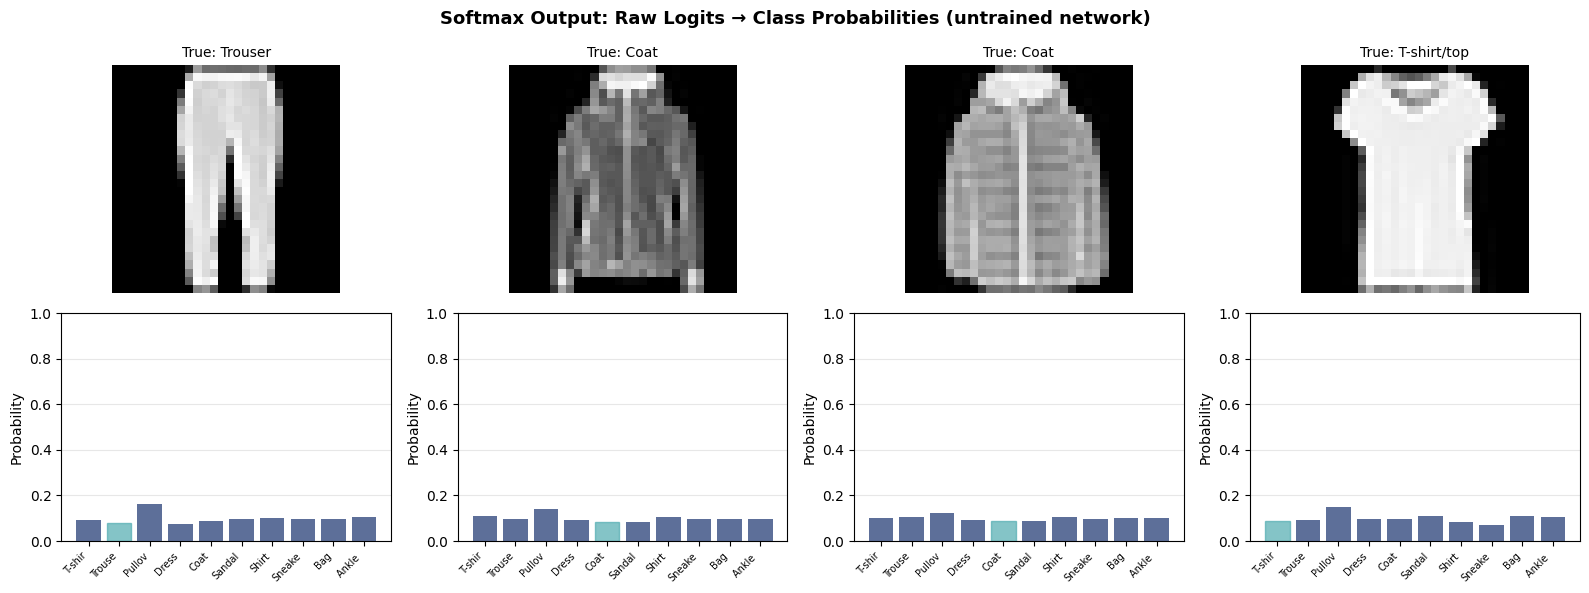

In [16]:
# Visualization: softmax in action on real FashionMNIST samples
# Pass a few test images through a random (untrained) network and show predicted probabilities

demo_model = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))

# Get 4 random test images
torch.manual_seed(0)
indices = torch.randint(0, len(test_dataset), (4,))
images = torch.stack([test_dataset[i][0] for i in indices])
labels = [test_dataset[i][1] for i in indices]

with torch.no_grad():
    logits = demo_model(images)
    probs = torch.softmax(logits, dim=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i in range(4):
    # Show image
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'True: {class_names[labels[i]]}', fontsize=10)
    axes[0, i].axis('off')
    
    # Show softmax probabilities
    bars = axes[1, i].bar(range(10), probs[i].numpy(), color=C1, alpha=0.7)
    bars[labels[i]].set_color(C2)  # highlight correct class
    axes[1, i].set_xticks(range(10))
    axes[1, i].set_xticklabels([n[:6] for n in class_names], rotation=45, ha='right', fontsize=7)
    axes[1, i].set_ylabel('Probability')
    axes[1, i].set_ylim(0, 1)
    axes[1, i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Softmax Output: Raw Logits → Class Probabilities (untrained network)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 1.1** — PyTorch's `CrossEntropyLoss` takes **raw logits**, not probabilities. Why? What numerical problem would arise if you applied softmax first and then took the log separately? 
>
> *Hint:* think about what happens when one logit is much larger than the others.
>
> Logits prevent a floating point precision error caused by extremely small probabillities rounding to zero (at softmax). For which log() is -infinity.

> **Question 1.2** — From the lecture: least squares loss assumes Gaussian-distributed outputs, and cross-entropy assumes categorical outputs. What would happen if you used **MSE loss for classification** (with one-hot encoded targets)? We'll test this empirically in Section 3 — write down your prediction now.
>
> MSE would saturate faster (when wrong), cross-entropy would mantain a stronger gradient signal/sentiment.

---

## 2. Gradient Inspection and Backpropagation

From Lecture 5, we know that **backpropagation** efficiently computes gradients of the loss with respect to every parameter via the chain rule. PyTorch's `autograd` handles this automatically — but it's important to understand what it's actually computing.

In this section, you'll build a tiny network with known weights, run a forward and backward pass, and verify the gradients by hand.

### Exercise 2.1 — Inspect gradients on a tiny network

Build a small network with **fixed, known weights**: `nn.Linear(2, 3)` → `nn.ReLU()` → `nn.Linear(3, 1)`. Set the weights manually (code provided below). Then:
1. Run a forward pass with input `x = [1.0, 2.0]` and target `y = 1.0`
2. Compute MSE loss
3. Call `.backward()`
4. Print the gradient (`.grad`) for every parameter using `named_parameters()`

In [17]:
# Build tiny network with known weights
tiny_net = nn.Sequential(
    nn.Linear(2, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

# Set weights manually for reproducibility
with torch.no_grad():
    # Layer 0 (Linear 2→3): W shape (3,2), b shape (3,)
    tiny_net[0].weight.copy_(torch.tensor([[ 0.5, -0.3],
                                            [ 0.2,  0.8],
                                            [-0.4,  0.1]]))
    tiny_net[0].bias.copy_(torch.tensor([0.1, -0.2, 0.3]))
    
    # Layer 2 (Linear 3→1): W shape (1,3), b shape (1,)
    tiny_net[2].weight.copy_(torch.tensor([[0.6, -0.5, 0.4]]))
    tiny_net[2].bias.copy_(torch.tensor([0.1]))

x = torch.tensor([[1.0, 2.0]])  # single input
y = torch.tensor([[1.0]])        # target

# 1. Forward pass: compute prediction
pred = tiny_net(x)
# 2. Compute MSE loss (use nn.MSELoss())
loss = nn.MSELoss()(pred, y) # prediction and target
# 3. Call .backward()
loss.backward()
# 4. Print gradients for each parameter
for name, param in tiny_net.named_parameters():
    print(f"{name:<20} | grad shape: {str(list(param.grad.shape)):<10} | grad norm: {param.grad.norm().item():.4f}")

0.weight             | grad shape: [3, 2]     | grad norm: 4.7535
0.bias               | grad shape: [3]        | grad norm: 2.1258
2.weight             | grad shape: [1, 3]     | grad norm: 5.3224
2.bias               | grad shape: [1]        | grad norm: 3.3200


### Exercise 2.2 — Verify a gradient by hand

Let's trace the computation manually for the **output layer bias** $b_2$. The forward pass computes:

$$\mathbf{f}_0 = W_1 \mathbf{x} + \mathbf{b}_1 \quad \rightarrow \quad \mathbf{h}_1 = \text{ReLU}(\mathbf{f}_0) \quad \rightarrow \quad \hat{y} = W_2 \mathbf{h}_1 + b_2$$

The MSE loss is $L = (\hat{y} - y)^2$. By the chain rule:

$$\frac{\partial L}{\partial b_2} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial b_2} = 2(\hat{y} - y) \cdot 1$$

Compute this value numerically using the intermediate values from your forward pass. Does it match the autograd gradient?

In [19]:
# Step 1: compute the forward pass intermediate values manually

# We extract the weight and bias tensors defined in Exercise 2.1
W1 = tiny_net[0].weight.data # Shape (3, 2)
b1 = tiny_net[0].bias.data   # Shape (3,)
W2 = tiny_net[2].weight.data # Shape (1, 3)
b2 = tiny_net[2].bias.data   # Shape (1,)
# f0 = W1 @ x + b1 (pre-activation of hidden layer)
# h1 = ReLU(f0)
# y_hat = W2 @ h1 + b2

# Note: PyTorch Linear layers compute x @ W.T + b
f0 = x @ W1.T + b1           # Pre-activation: (1, 2) @ (2, 3) + (3,) -> (1, 3)
h1 = torch.relu(f0)          # Hidden activation
y_hat = h1 @ W2.T + b2       # Final prediction: (1, 3) @ (3, 1) + (1,) -> (1, 1)

# Step 2: compute dL/db2 = 2 * (y_hat - y) * 1

# This follows the chain rule: (dL/dy_hat) * (dy_hat/db2)
# For a single sample, MSE is (y_hat - y)^2, so dL/dy_hat = 2 * (y_hat - y)
manual_grad_b2 = 2 * (y_hat - y) * 1.0
# (note: nn.MSELoss uses mean, so for a single sample it's just (y_hat - y)^2,
#  and the gradient is 2*(y_hat - y))

# Step 3: compare with the autograd gradient from Exercise 2.1
# The autograd gradient for b2 is stored in tiny_net[2].bias.grad
autograd_grad_b2 = tiny_net[2].bias.grad

print(f"Manual y_hat    : {y_hat.item():.6f}")
print(f"Manual dL/db2   : {manual_grad_b2.item():.6f}")
print(f"Autograd dL/db2 : {autograd_grad_b2.item():.6f}")

# Verification check
assert torch.allclose(manual_grad_b2, autograd_grad_b2), "Gradients do not match!"
print("✓ Manual gradient matches autograd calculation!")

Manual y_hat    : -0.660000
Manual dL/db2   : -3.320000
Autograd dL/db2 : -3.320000
✓ Manual gradient matches autograd calculation!


> **Question 2.1** — Look at the gradient magnitudes for each parameter in the tiny network. Which layer has the largest gradients? Which has the smallest? What does this suggest about how information flows backward through the network?
>
> Layers closer to the output have larger and the largest gradients. Earlier layers multiply the output by intermediate derivatives (chain), reducing the magnitude. 

### Exercise 2.3 — Gradient norms across layers in a deeper network

Now let's scale up. Build a 5-layer network (width 64, ReLU activations), forward-pass a batch of 256 random inputs, compute a cross-entropy loss against random labels, and record the **mean gradient norm** of each weight matrix after `.backward()`.

This will give us our first look at how gradients behave in deeper networks — a preview of Section 4.

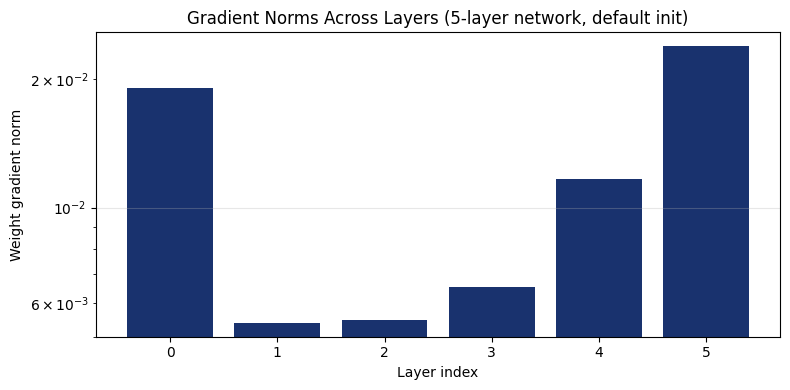

In [21]:
# 1. Build a 5-hidden-layer network: 784 → 64 → 64 → 64 → 64 → 64 → 10
#    Use nn.Sequential with nn.Linear and nn.ReLU, start with nn.Flatten()
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 10)
)

# 2. Forward-pass a batch of 256 random inputs (shape: 256, 1, 28, 28)
x_rand = torch.randn(256, 1, 28, 28)

# 3. Compute CrossEntropyLoss against random labels (0-9)
labels = torch.randint(0, 10, (256,))
loss = nn.CrossEntropyLoss()(model(x_rand), labels)

# 4. Call .backward()
loss.backward()
# 5. Collect gradient norms: for each Linear layer, compute layer.weight.grad.norm().item()
#    Store in a list called grad_norms
grad_norms = [layer.weight.grad.norm().item() for layer in model if isinstance(layer, nn.Linear)]

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(grad_norms)), grad_norms, color=C1)
ax.set_xlabel('Layer index')
ax.set_ylabel('Weight gradient norm')
ax.set_title('Gradient Norms Across Layers (5-layer network, default init)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

> **Question 2.2** — Do you see a trend in gradient magnitudes across layers? Do gradients grow or shrink as you go from the output layer toward the input? What does this imply for training the early layers of a deep network?
>
> They shrink. Implying earlier layers learn much slower.

---

## 3. The Optimizer Showdown

From Lecture 5, we learned three optimizers of increasing sophistication:

| Optimizer | Update rule | Key idea |
|-----------|------------|----------|
| **SGD** | $\boldsymbol{\phi} \leftarrow \boldsymbol{\phi} - \alpha \nabla L$ | Follow the (noisy) gradient |
| **SGD + Momentum** | Accumulate exponential moving average of gradients | Smooth out oscillations |
| **Adam** | Adaptive per-parameter learning rates + momentum | Robust to learning rate choice |

But how different are they in practice? In this section, you'll train the **same architecture** with each optimizer and systematically vary the learning rate. This is the kind of experiment you'll do routinely when developing real models.

We use a 4-hidden-layer network with ~25K parameters (similar to Notebook 3), with **He initialization** applied from the start (we'll understand *why* in Section 4).

In [22]:
# Shared architecture and utilities for all experiments in this section

def make_model():
    """Create a fresh 4-hidden-layer network with He initialization (~25K params).
    Architecture: 784 → 48 → 48 → 48 → 48 → 10
    """
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 48), nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 10)
    )
    # Apply He initialization
    for m in model:
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight)
            m.bias.data.fill_(0.0)
    return model

# Verify parameter count
info = summary(make_model(), input_size=(1, 1, 28, 28), verbose=0)
print(f"Model parameters: {info.total_params:,}")


# Training utilities (same pattern as Notebooks 2-3)
def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns (avg_loss, accuracy %)."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns (avg_loss, accuracy %)."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), 100. * correct / total


def run_experiment(model_fn, optimizer_fn, num_epochs, train_loader, test_loader,
                   criterion=None, device=device):
    """Train a model and return history dict.
    
    Args:
        model_fn: callable that returns a fresh model
        optimizer_fn: callable that takes model.parameters() and returns an optimizer
        num_epochs: number of epochs to train
        train_loader, test_loader: data loaders
        criterion: loss function (default: CrossEntropyLoss)
        device: torch device
    Returns:
        dict with keys: train_loss, test_loss, train_acc, test_acc (lists)
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    
    model = model_fn().to(device)
    optimizer = optimizer_fn(model.parameters())
    
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
    
    return history

Model parameters: 45,226


### Experiment 3.1 — Optimizer type comparison

Train the same architecture with three optimizers, all using `lr=0.01`, for **15 epochs**. Use the `run_experiment` helper — you just need to define the optimizer functions.

In [23]:
NUM_EPOCHS_3 = 15

# Define optimizer functions and run experiments
# Each optimizer_fn should take model.parameters() as input and return an optimizer
#
optimizers = {
    'SGD':          lambda params: optim.SGD(params, lr=0.01),
    'SGD+Momentum': lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    'Adam':         lambda params: optim.Adam(params, lr=0.01),
}
#
results_3_1 = {}
for name, opt_fn in optimizers.items():
    results_3_1[name] = run_experiment(make_model, opt_fn, NUM_EPOCHS_3,
                                        train_loader, test_loader)
    print(f"{name:>15s}  |  Test acc: {results_3_1[name]['test_acc'][-1]:.1f}%")

            SGD  |  Test acc: 85.1%
   SGD+Momentum  |  Test acc: 87.0%
           Adam  |  Test acc: 86.6%


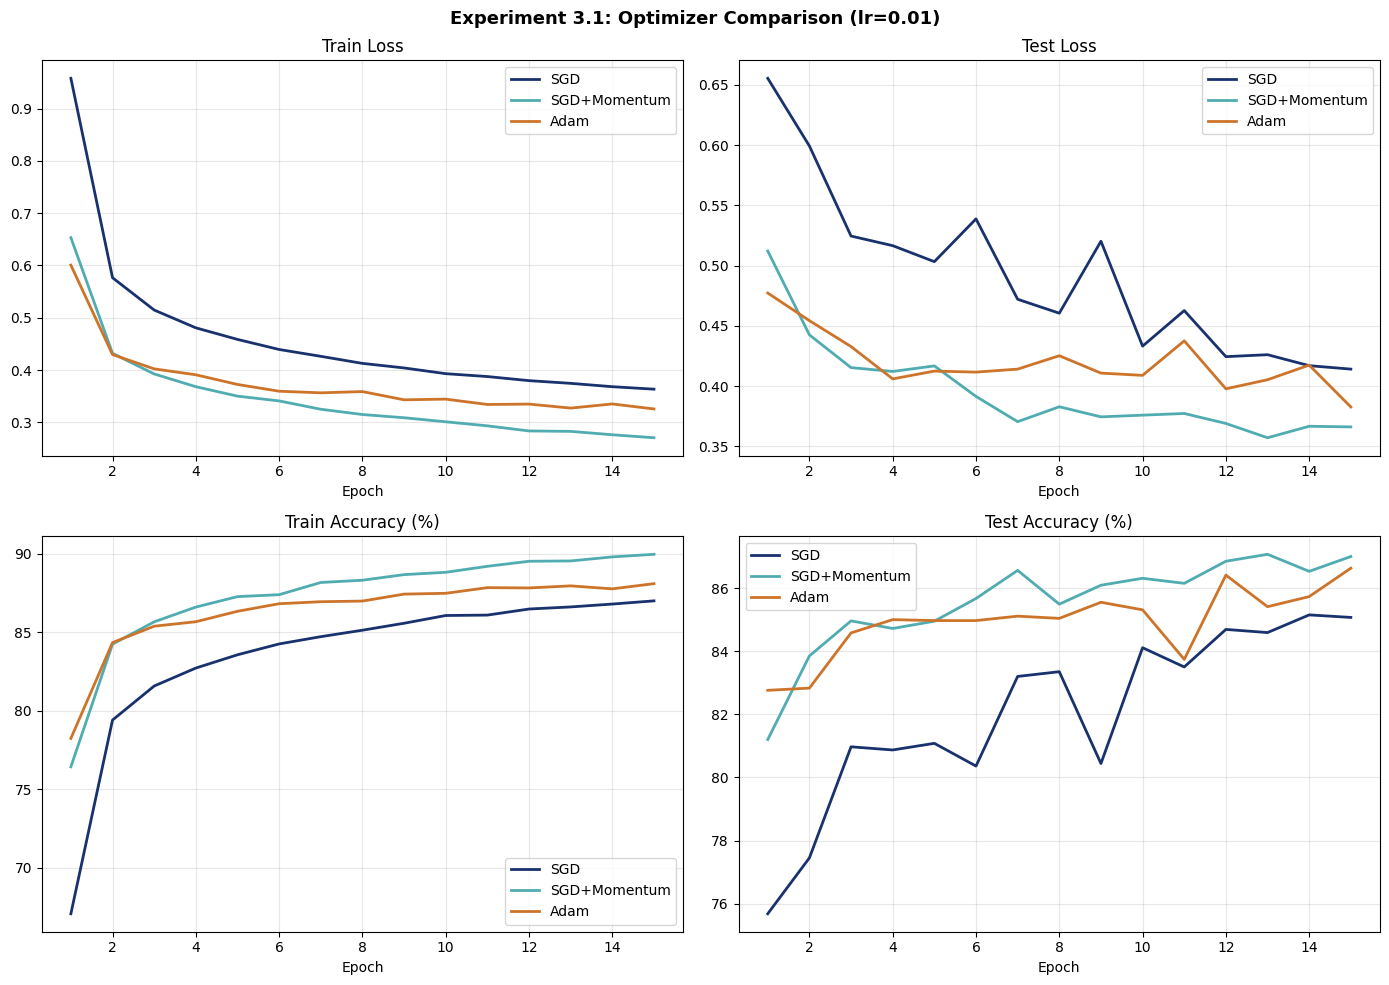

In [24]:
# Visualization: 2x2 grid of training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_opt = [C1, C2, C3]
epochs_range = range(1, NUM_EPOCHS_3 + 1)

for (name, hist), color in zip(results_3_1.items(), colors_opt):
    axes[0, 0].plot(epochs_range, hist['train_loss'], color=color, linewidth=2, label=name)
    axes[0, 1].plot(epochs_range, hist['test_loss'],  color=color, linewidth=2, label=name)
    axes[1, 0].plot(epochs_range, hist['train_acc'],  color=color, linewidth=2, label=name)
    axes[1, 1].plot(epochs_range, hist['test_acc'],   color=color, linewidth=2, label=name)

titles = ['Train Loss', 'Test Loss', 'Train Accuracy (%)', 'Test Accuracy (%)']
for ax, title in zip(axes.flat, titles):
    ax.set_xlabel('Epoch'); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 3.1: Optimizer Comparison (lr=0.01)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 3.1** — Comparing the three optimizers at lr=0.01:
> 1. Which optimizer converges fastest (reaches high accuracy in the fewest epochs)?
> 2. Which reaches the best final test accuracy?
> 3. Does momentum help SGD? By how much?
>
> 1) Adam reaches a plateau faster.
> 2) SGD + Momentum
> 3) +~2%

### Experiment 3.2 — Learning rate sensitivity

Now we test how sensitive each optimizer is to the learning rate. For each of the three optimizers, train with learning rates `[0.0001, 0.001, 0.01, 0.1]`. That's **12 training runs** — this may take a few minutes.

Use 10 epochs per run to save time.

In [25]:
NUM_EPOCHS_LR = 10
learning_rates = [0.0001, 0.001, 0.01, 0.1]

# YOUR CODE HERE: run 12 experiments (3 optimizers x 4 learning rates)
# Store results in a nested dict: results_3_2[optimizer_name][lr] = history

optimizer_configs = {
    'SGD':          lambda params, lr: optim.SGD(params, lr=lr),
    'SGD+Momentum': lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    'Adam':         lambda params, lr: optim.Adam(params, lr=lr),
}

results_3_2 = {}
for opt_name, opt_factory in optimizer_configs.items():
    results_3_2[opt_name] = {}
    for lr in learning_rates:
        opt_fn = lambda params, _lr=lr: opt_factory(params, _lr)
        results_3_2[opt_name][lr] = run_experiment(
            make_model, opt_fn, NUM_EPOCHS_LR, train_loader, test_loader)
        print(f"{opt_name:>15s}  lr={lr:.4f}  |  Test: {results_3_2[opt_name][lr]['test_acc'][-1]:.1f}%")


            SGD  lr=0.0001  |  Test: 39.9%
            SGD  lr=0.0010  |  Test: 77.2%
            SGD  lr=0.0100  |  Test: 83.1%
            SGD  lr=0.1000  |  Test: 86.2%
   SGD+Momentum  lr=0.0001  |  Test: 75.9%
   SGD+Momentum  lr=0.0010  |  Test: 84.2%
   SGD+Momentum  lr=0.0100  |  Test: 86.6%
   SGD+Momentum  lr=0.1000  |  Test: 85.7%
           Adam  lr=0.0001  |  Test: 85.2%
           Adam  lr=0.0010  |  Test: 86.5%
           Adam  lr=0.0100  |  Test: 85.3%
           Adam  lr=0.1000  |  Test: 10.0%


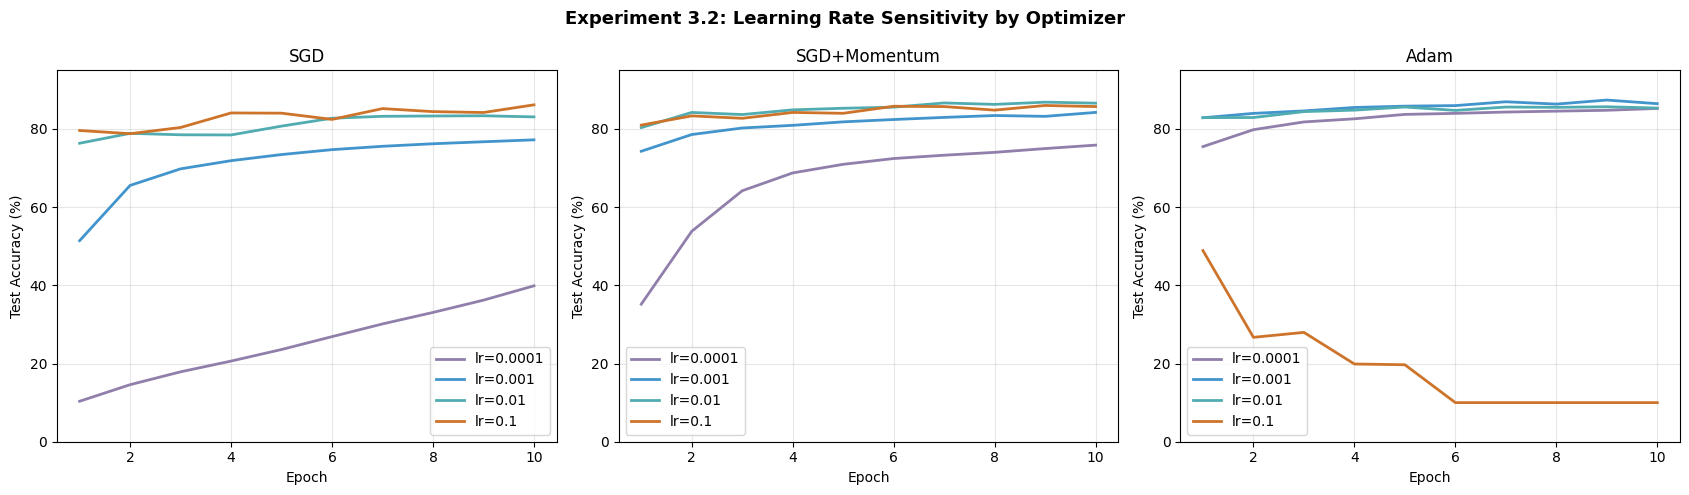

In [26]:
# Visualization: 3x1 grid — one subplot per optimizer, curves for each learning rate
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
lr_colors = [C5, C6, C2, C3]
epochs_range = range(1, NUM_EPOCHS_LR + 1)

for ax, (opt_name, lr_results) in zip(axes, results_3_2.items()):
    for (lr, hist), color in zip(lr_results.items(), lr_colors):
        ax.plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=f'lr={lr}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(opt_name); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 95)

plt.suptitle('Experiment 3.2: Learning Rate Sensitivity by Optimizer', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 3.2** — Analyzing learning rate sensitivity:
> 1. Which optimizer is **most sensitive** to the learning rate choice? Which is **most robust**?
> 2. Why does Adam tolerate a wider range of learning rates? Connect your answer to the lecture's explanation of per-parameter adaptive rates (the division by $\sqrt{\tilde{\mathbf{v}}}$).
>
> 1) SGD is the most sensitive. Adam is the most robust.

> **Question 3.3** — What happens with `lr=0.1` for SGD without momentum? For Adam? Explain the difference in behavior.
>
> SGD learns but its not very stable. Adam seems to diverge, updates are too large for the loss to fall into the gradient (given that adam scales its updates based on the previous gradient). So it becomes very unstable and bad.

### Experiment 3.3 — Cross-Entropy vs MSE for classification

In Question 1.2, you predicted what would happen if we used MSE loss for classification. Let's test it.

Using the best optimizer and learning rate from the experiments above, train two models for 15 epochs:
- One with `nn.CrossEntropyLoss()` (the correct choice from maximum likelihood)
- One with `nn.MSELoss()` using **one-hot encoded targets**

> **Note:** To use MSE for classification, you need to convert integer labels to one-hot vectors. We provide a helper and a wrapper loss below.

In [28]:
# Helper: MSE loss that accepts integer labels (converts to one-hot internally)
class MSEClassificationLoss(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.mse = nn.MSELoss()
    
    def forward(self, logits, targets):
        one_hot = torch.zeros_like(logits).scatter_(1, targets.unsqueeze(1), 1.0)
        return self.mse(logits, one_hot)


# Run two experiments — CrossEntropyLoss vs MSEClassificationLoss
# Use the best optimizer and learning rate you found in Experiments 3.1/3.2
# Store results in results_3_3 dict with keys 'CrossEntropy' and 'MSE'

results_3_3 = {}
results_3_3['CrossEntropy'] = run_experiment(
    make_model, lambda p: optim.Adam(p, lr=0.01), 15,
    train_loader, test_loader, criterion=nn.CrossEntropyLoss())
results_3_3['MSE'] = run_experiment(
    make_model, lambda p: optim.Adam(p, lr=0.01), 15,
    train_loader, test_loader, criterion=MSEClassificationLoss())

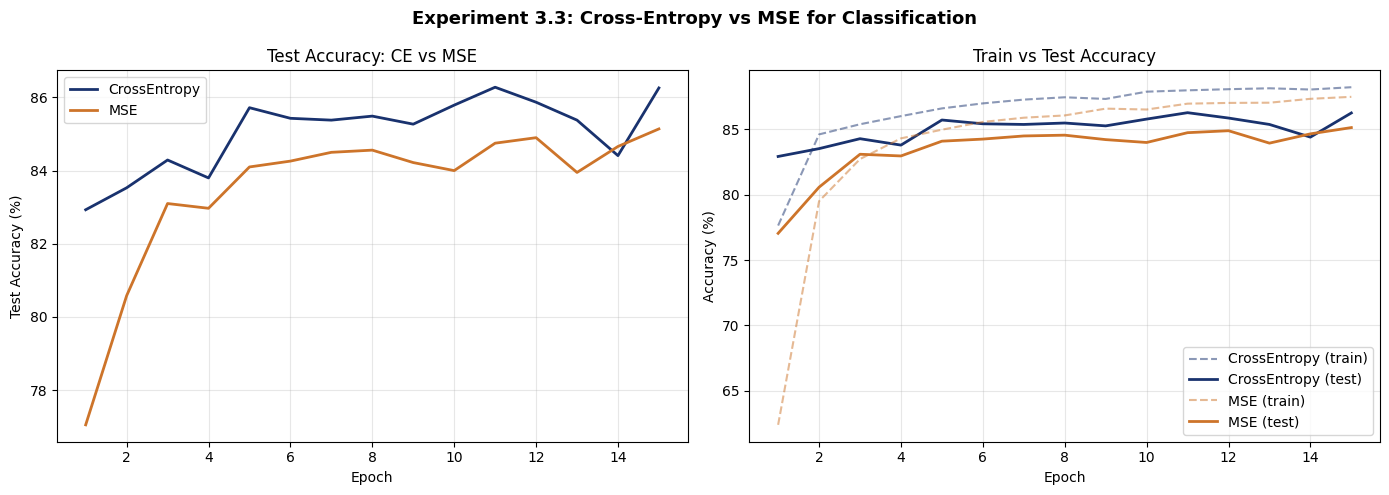

  CrossEntropy  |  Final test acc: 86.3%
           MSE  |  Final test acc: 85.1%


In [29]:
# Visualization: CE vs MSE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loss_colors = [C1, C3]
epochs_range = range(1, 16)

for (name, hist), color in zip(results_3_3.items(), loss_colors):
    axes[0].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=name)
    axes[1].plot(epochs_range, hist['train_acc'], '--', color=color, linewidth=1.5, alpha=0.5, label=f'{name} (train)')
    axes[1].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=f'{name} (test)')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy: CE vs MSE'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Train vs Test Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Experiment 3.3: Cross-Entropy vs MSE for Classification', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for name, hist in results_3_3.items():
    print(f"{name:>14s}  |  Final test acc: {hist['test_acc'][-1]:.1f}%")

> **Question 3.4** — Comparing cross-entropy vs MSE for classification:
> 1. How does MSE compare to cross-entropy in convergence speed and final accuracy?
> 2. Did this match your prediction from Question 1.2?
> 3. Why might cross-entropy be preferred even if MSE eventually works? Think about the gradient behavior: for cross-entropy, the gradient is proportional to $(p_k - y_k)$; for MSE applied to logits, what happens to the gradient when the logits are far from the one-hot target?
>
> 1) Cross entropy is faster and more accurate.
> 2) yes, I predicted cross entropy having a better gradient signal.
> 3) For MSE, when logits are far from the one-hot target, the gradient can become very small (saturate), leading to slow learning. cross entropy maintains a stronger gradient signal even when predictions are wrong, which helps the model learn more effectively.

---

## 4. Initialization Matters (Optional)

In Section 3, we quietly used **He initialization** (`kaiming_normal_`) without explaining why. Now let's understand what happens without it.

From Lecture 5, each layer transforms the variance of activations by a factor of $\frac{1}{2}D_h\sigma_\Omega^2$ (the $\frac{1}{2}$ comes from ReLU clipping half the values). If this factor is:
- **Less than 1** ($\sigma_\Omega^2 < 2/D_h$): activations shrink layer by layer → **vanishing gradients**
- **Greater than 1** ($\sigma_\Omega^2 > 2/D_h$): activations grow layer by layer → **exploding gradients**
- **Equal to 1** ($\sigma_\Omega^2 = 2/D_h$): activations stay stable → **He initialization**

Let's make this concrete with a 20-layer network.

### Exercise 4.1 — Activation variance propagation

Build a 20-layer ReLU network (width 100, no training). Initialize the weights with three different scales:
1. `nn.init.normal_(w, std=0.01)` — too small
2. `nn.init.normal_(w, std=1.0)` — too large
3. `nn.init.kaiming_normal_(w)` — He initialization

For each initialization, forward-pass a batch of 256 random inputs and record the **variance of activations** at each layer. Plot all three on one figure (use log scale for the y-axis).

In [ ]:
def make_deep_net(num_layers=20, width=100):
    """Create a deep ReLU network (no Flatten — expects flat input)."""
    layers = [nn.Linear(width, width), nn.ReLU()]
    for _ in range(num_layers - 1):
        layers += [nn.Linear(width, width), nn.ReLU()]
    return nn.Sequential(*layers)


def init_weights(model, mode='he'):
    """Initialize all Linear layers with a given mode."""
    for m in model:
        if isinstance(m, nn.Linear):
            if mode == 'small':
                nn.init.normal_(m.weight, std=0.01)
            elif mode == 'large':
                nn.init.normal_(m.weight, std=1.0)
            elif mode == 'he':
                nn.init.kaiming_normal_(m.weight)
            m.bias.data.fill_(0.0)


def measure_activation_variance(model, x):
    """Forward pass, recording activation variance after each ReLU.
    
    Returns:
        list of variance values, one per layer
    """
    variances = []
    h = x
    for layer in model:
        h = layer(h)
        if isinstance(layer, nn.ReLU):
            variances.append(h.var().item())
    return variances


# YOUR CODE HERE
# 1. Create three copies of the 20-layer network
# 2. Initialize each with a different mode: 'small', 'large', 'he'
# 3. Forward-pass the same random input (shape: 256, 100) through each
# 4. Collect activation variances using measure_activation_variance
# Store results in a dict: act_variances = {'small': [...], 'large': [...], 'he': [...]}

raise NotImplementedError()

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
init_colors = {'small': C4, 'large': C3, 'he': C2}
init_labels = {'small': 'std=0.01 (too small)', 'large': 'std=1.0 (too large)', 'he': 'He init (just right)'}

for mode, variances in act_variances.items():
    ax.plot(range(1, len(variances) + 1), variances, 'o-',
            color=init_colors[mode], linewidth=2, markersize=4, label=init_labels[mode])

ax.set_xlabel('Layer'); ax.set_ylabel('Activation Variance (log scale)')
ax.set_title('Activation Variance Across 20 Layers')
ax.set_yscale('log'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

> **Question 4.1** — Analyzing the activation variance plot:
> 1. What happens to the activation variance with `std=0.01`? With `std=1.0`? Describe the trend.
> 2. Why does He initialization keep the variance approximately stable?
> 3. Use the formula from the lecture: $\text{Var}(f') = \frac{1}{2}D_h \sigma_\Omega^2 \cdot \text{Var}(f)$. For `width=100`, what value of $\sigma_\Omega^2$ makes this ratio equal to 1? Verify this matches what `kaiming_normal_` uses.
>
> *Your answer here:*

### Exercise 4.2 — Gradient variance propagation

Now let's look at the backward pass. Using the same three initializations, compute a loss on random data, call `.backward()`, and record the **gradient norm of each weight matrix**. This mirrors the activation analysis but for gradients.

In [ ]:
def measure_gradient_norms(model, x, y):
    """Forward + backward pass, recording weight gradient norms per layer.
    
    Returns:
        list of gradient norms, one per Linear layer (from input to output)
    """
    criterion = nn.MSELoss()
    pred = model(x)
    loss = criterion(pred, y)
    loss.backward()
    
    grad_norms = []
    for m in model:
        if isinstance(m, nn.Linear):
            grad_norms.append(m.weight.grad.norm().item())
    return grad_norms


# YOUR CODE HERE
# Same setup as Exercise 4.1, but now measure gradient norms
# 1. Create three 20-layer networks with different initializations
# 2. Forward-pass the same random input (256, 100), target shape (256, 100)
# 3. Collect gradient norms using measure_gradient_norms
# Store results in: grad_norms_by_init = {'small': [...], 'large': [...], 'he': [...]}

raise NotImplementedError()

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))

for mode, norms in grad_norms_by_init.items():
    ax.plot(range(1, len(norms) + 1), norms, 'o-',
            color=init_colors[mode], linewidth=2, markersize=4, label=init_labels[mode])

ax.set_xlabel('Layer (from input to output)')
ax.set_ylabel('Weight Gradient Norm (log scale)')
ax.set_title('Gradient Norms Across 20 Layers')
ax.set_yscale('log'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

> **Question 4.2** — Comparing activation and gradient propagation:
> 1. Do the gradient norms mirror the activation variance pattern? For which initialization do gradients vanish? Explode?
> 2. What would happen if you tried to train the `std=0.01` network? Would the early layers learn anything? Why or why not?
>
> *Your answer here:*

### Exercise 4.3 — Training impact of initialization

Now let's see how initialization affects actual training. Using the best optimizer and learning rate from Section 3, train the 4-hidden-layer FashionMNIST model with three initialization schemes:
1. `std=0.01` (too small)
2. `std=1.0` (too large)
3. He initialization

15 epochs each. Also try this with a shallower 1-layer network to see if initialization matters equally for shallow vs deep architectures.

In [ ]:
def make_model_with_init(mode='he'):
    """Create the 4-layer model with a specific initialization."""
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 48), nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 10)
    )
    for m in model:
        if isinstance(m, nn.Linear):
            if mode == 'small':
                nn.init.normal_(m.weight, std=0.01)
            elif mode == 'large':
                nn.init.normal_(m.weight, std=1.0)
            elif mode == 'he':
                nn.init.kaiming_normal_(m.weight)
            m.bias.data.fill_(0.0)
    return model


def make_shallow_with_init(mode='he'):
    """Create a 1-layer model with a specific initialization."""
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256), nn.ReLU(),
        nn.Linear(256, 10)
    )
    for m in model:
        if isinstance(m, nn.Linear):
            if mode == 'small':
                nn.init.normal_(m.weight, std=0.01)
            elif mode == 'large':
                nn.init.normal_(m.weight, std=1.0)
            elif mode == 'he':
                nn.init.kaiming_normal_(m.weight)
            m.bias.data.fill_(0.0)
    return model


# YOUR CODE HERE: train both architectures with all three initializations
# Use the best optimizer from Section 3 (likely Adam with lr=0.001)
# 
# init_modes = ['small', 'large', 'he']
# results_4_3_deep = {}
# results_4_3_shallow = {}
#
# for mode in init_modes:
#     results_4_3_deep[mode] = run_experiment(
#         lambda m=mode: make_model_with_init(m),
#         lambda p: optim.Adam(p, lr=???), 15, train_loader, test_loader)
#     results_4_3_shallow[mode] = run_experiment(
#         lambda m=mode: make_shallow_with_init(m),
#         lambda p: optim.Adam(p, lr=???), 15, train_loader, test_loader)
#     print(f"Init={mode:>5s}  |  Deep: {results_4_3_deep[mode]['test_acc'][-1]:.1f}%  "
#           f"|  Shallow: {results_4_3_shallow[mode]['test_acc'][-1]:.1f}%")

raise NotImplementedError()

In [ ]:
# Visualization: side-by-side comparison — deep vs shallow
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, 16)

for (mode, hist), color in zip(results_4_3_deep.items(), [C4, C3, C2]):
    axes[0].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=init_labels[mode])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Deep Network (4 hidden layers)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for (mode, hist), color in zip(results_4_3_shallow.items(), [C4, C3, C2]):
    axes[1].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=init_labels[mode])
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Shallow Network (1 hidden layer)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Exercise 4.3: Effect of Initialization — Deep vs Shallow', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 4.3** — Initialization and network depth:
> 1. Does initialization matter more for the **deep** or **shallow** network? Compare the gap between the best and worst initialization for each.
> 2. Why does depth amplify the effect of bad initialization? Think about how the multiplication factor $\frac{1}{2}D_h\sigma_\Omega^2$ compounds across layers.
> 3. Based on everything you've seen in this section, would you ever train a deep network without He initialization? Why or why not?
>
> *Your answer here:*

---

## 5. Batch Size Effects

From Lecture 5, we know that **SGD** estimates the gradient using a random mini-batch. The batch size controls the noise level:
- **Small batches** → noisier gradients → more exploration, potential regularization effect
- **Large batches** → smoother gradients → faster per epoch (better GPU utilization), but may converge to sharper minima

Let's test this empirically.

### Exercise 5.1 — Batch size sweep

Train the best configuration from Section 3 (best optimizer, best lr, He init) with batch sizes `[32, 128, 256, 1024]`. Use 15 epochs.

You'll need to create **new DataLoaders** with each batch size.

In [ ]:
results_5 = {}
batch_sizes = [32, 128, 256, 1024]

# For each batch size:
for bs in batch_sizes:
    # 1. Create new DataLoaders with that batch size
    bs_train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    bs_test_loader  = DataLoader(test_dataset,  batch_size=bs, shuffle=False)

    # 2. Train using run_experiment with make_model and best optimizer
    # 3. Store results in results_5 dict keyed by batch size
    results_5[bs] = run_experiment(
        make_model, lambda p: optim.Adam(p, lr=0.01), 15,
        bs_train_loader, bs_test_loader)
    print(f"Batch size {bs:>5d}  |  Test acc: {results_5[bs]['test_acc'][-1]:.1f}%")

Starting training for Batch Size: 32...
Batch size    32  |  Test acc: 78.4%
Starting training for Batch Size: 128...
Batch size   128  |  Test acc: 84.9%
Starting training for Batch Size: 256...
Batch size   256  |  Test acc: 86.5%
Starting training for Batch Size: 1024...
Batch size  1024  |  Test acc: 87.1%


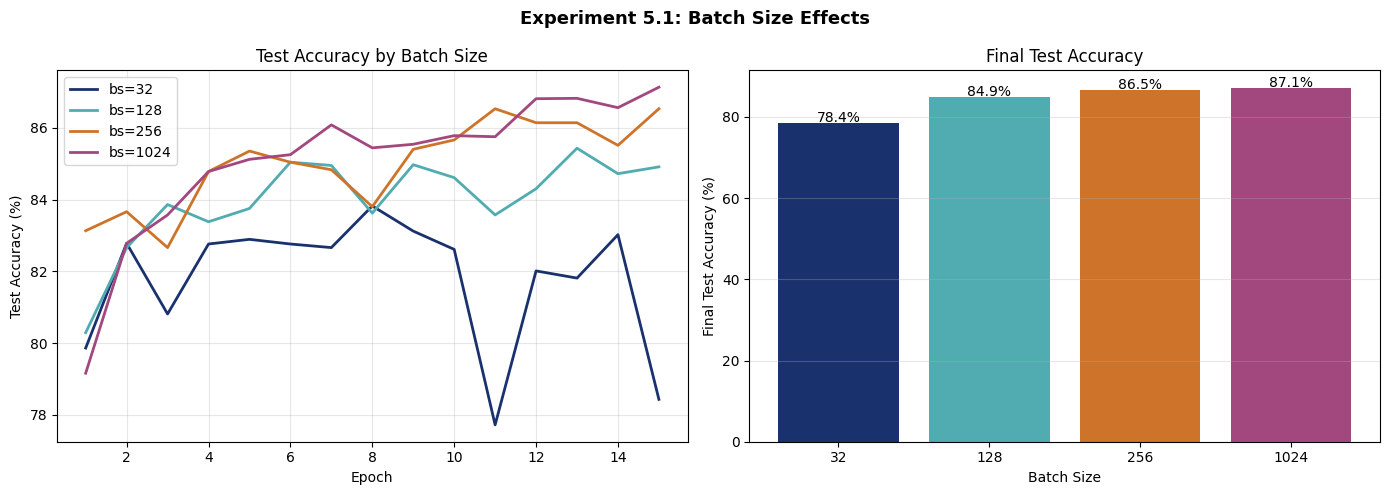

In [32]:
# Visualization: accuracy curves + final accuracy bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_colors = [C1, C2, C3, C4]
epochs_range = range(1, 16)

for (bs, hist), color in zip(results_5.items(), bs_colors):
    axes[0].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=f'bs={bs}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy by Batch Size'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

final_accs = [results_5[bs]['test_acc'][-1] for bs in batch_sizes]
bars = axes[1].bar([str(bs) for bs in batch_sizes], final_accs, color=bs_colors)
axes[1].set_xlabel('Batch Size'); axes[1].set_ylabel('Final Test Accuracy (%)')
axes[1].set_title('Final Test Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, final_accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', fontsize=10)

plt.suptitle('Experiment 5.1: Batch Size Effects', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 5.1** — Analyzing batch size effects:
> 1. How does batch size affect **convergence speed** (how fast accuracy rises in early epochs)?
> 2. How does batch size affect **final accuracy**? Do smaller batches generalize better?
> 3. The lecture says smaller batches add noise that helps escape local minima. Do you see evidence of this in your results?
>
> 1) Higher batch sizes make training considerably more accurate.
> 2) No it doesn't.
> 3) I see evidence of noise making sharp bounces (stochastic noise) which would hep the optimizer from getting stuck in a bad minima, yet in practice (results) don't support this as a positive statement.

> **Question 5.2** — Larger batches are faster per epoch (better GPU utilization) but may need more epochs. Smaller batches see more parameter updates per epoch. If you had a fixed **wall-clock time budget**, what batch size would you choose and why?
>
> Considering a GPU with parallel processing then smaller batches would underutilize my processing, yet its important to provide enough parameter updates per epoch so to reach high accuracy before deadline (done by higher batches). So I would choose a medium to large batch size, such as 256.

---

## Optional: Learning Rate Schedules

In all experiments so far, we've used a **constant learning rate**. But the lecture mentions that it's common practice to **decrease the learning rate** over time: start with a high rate for fast exploration, then reduce it for fine-tuning near the optimum.

PyTorch provides several scheduling strategies in `torch.optim.lr_scheduler`. Two popular ones:
- **StepLR**: multiply the learning rate by `gamma` every `step_size` epochs
- **CosineAnnealingLR**: smoothly decay the learning rate following a cosine curve from the initial value to near zero

### Exercise O.1 — Comparing learning rate schedules

Train the best configuration from Section 3 with three strategies:
1. **Constant** learning rate (baseline)
2. **StepLR**: halve the learning rate every 5 epochs (`step_size=5, gamma=0.5`)
3. **CosineAnnealingLR**: smooth cosine decay over all epochs (`T_max=NUM_EPOCHS`)

Use **20 epochs** to give the schedules time to show their effect.

> **Note:** Schedulers need to be called once per epoch with `scheduler.step()`. We provide a modified training loop below.

In [ ]:
def run_experiment_with_scheduler(model_fn, optimizer_fn, scheduler_fn, num_epochs,
                                  train_loader, test_loader, device=device):
    """Train a model with a learning rate scheduler.
    
    Args:
        model_fn: callable returning a fresh model
        optimizer_fn: callable taking model.parameters(), returning optimizer
        scheduler_fn: callable taking optimizer, returning scheduler (or None for constant lr)
        num_epochs: number of epochs
    Returns:
        dict with train_loss, test_loss, train_acc, test_acc, lr_history
    """
    criterion = nn.CrossEntropyLoss()
    model = model_fn().to(device)
    optimizer = optimizer_fn(model.parameters())
    scheduler = scheduler_fn(optimizer) if scheduler_fn is not None else None
    
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': [], 'lr': []}
    for epoch in range(num_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        
        if scheduler is not None:
            scheduler.step()
        
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
    
    return history


NUM_EPOCHS_OPT = 20

# YOUR CODE HERE: run three experiments with different scheduler strategies
# Use the best optimizer and learning rate from Section 3
#
# schedule_configs = {
#     'Constant':  None,
#     'StepLR':    lambda opt: StepLR(opt, step_size=5, gamma=0.5),
#     'Cosine':    lambda opt: CosineAnnealingLR(opt, T_max=NUM_EPOCHS_OPT),
# }
#
# results_opt = {}
# for name, sched_fn in schedule_configs.items():
#     results_opt[name] = run_experiment_with_scheduler(
#         make_model,
#         lambda p: optim.Adam(p, lr=???),
#         sched_fn,
#         NUM_EPOCHS_OPT, train_loader, test_loader)
#     print(f"{name:>10s}  |  Test acc: {results_opt[name]['test_acc'][-1]:.1f}%")

raise NotImplementedError()

In [ ]:
# Visualization: LR schedule + test accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sched_colors = [C1, C2, C3]
epochs_range = range(1, NUM_EPOCHS_OPT + 1)

# Learning rate over time
for (name, hist), color in zip(results_opt.items(), sched_colors):
    axes[0].plot(epochs_range, hist['lr'], color=color, linewidth=2, label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Learning Rate')
axes[0].set_title('Learning Rate Schedule'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Test accuracy
for (name, hist), color in zip(results_opt.items(), sched_colors):
    axes[1].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=name)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Optional: Learning Rate Schedules', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for name, hist in results_opt.items():
    print(f"{name:>10s}  |  Final test acc: {hist['test_acc'][-1]:.1f}%")

> **Question O.1** — Learning rate schedules:
> 1. Does scheduling improve final accuracy compared to a constant learning rate?
> 2. Which schedule works better — StepLR or CosineAnnealing? At what point during training does the benefit become visible?
> 3. Why might reducing the learning rate late in training help? Think about the loss landscape near a minimum.
>
> *Your answer here:*

### Exercise O.2 — Your best FashionMNIST configuration

Combine the best choices from all sections — optimizer, learning rate, initialization, batch size, and learning rate schedule — into one final training run. Use 20 epochs and report your best test accuracy.

This is the best you've achieved on FashionMNIST so far in the course!

In [ ]:
# YOUR CODE HERE: combine your best choices
# - Best optimizer: ???
# - Best learning rate: ???
# - Initialization: He (kaiming_normal_)
# - Best batch size: ???
# - Best LR schedule: ???
#
# Train for 20 epochs and print the final test accuracy

raise NotImplementedError()